# Imports

- Evaluate the effect of timing of P-fertilizer

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
import pickle

import geopandas as gpd

In [2]:
from CAgsalML.causal import  dml_sensitivity_analysis
from CAgsalML.tuning import GPOptimizer
from CAgsalML.transformers import SpatialTransform

INFO (2025-11-27 15:41:17,593) [__init__/<module> (line 54)]: Using balance version 0.12.0


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import  r2_score
from sklearn.model_selection import train_test_split, cross_val_predict
from skopt.space import Categorical, Integer, Real

In [4]:
RANDOM_SEED = 43

In [13]:
data = pd.read_pickle('../data-definitive/data-dag.pkl')
adjustment_nodes = [
    'phenology', 'accessibilityRAI', 'knowledge', 'variety',
    'fertilizerTiming', 'weather', 'soil', 'techAccess',
    'previousAdvice', 'fieldHistory', 'elevation', 'neighborsAdvice',
    'crop', 'manure'
]
columns_dict = { # Includes all nodes, not only adjustment nodes
    'fieldHistory': [
        'fieldsize_value',  'history_maize', 'history_nocrop', 'history_legume',
        'history_rootandtuber', 'history_oilseed'
    ],
    'fertilizerAmount': ['fertN_total', 'fertP_total'],
    'accessibilityRAI': ['accessibility_rai'],
    'elevation': ['elevation_value'],
    'previousAdvice': ['treat_previousadvice'],
    'knowledge': ['knowledge_index'],
    'techAccess': ['techaccess_index'],
    'weather': [
        'wthseason_rain', 'wthseason_tmean', 'wthstage_rain0to10',
        'wthstage_rain10to30', 'wthstage_rain20to40', 'wthstage_rain30to50',
        'wthstage_rainp0to60', 'wthstage_rainp40to100'
    ],
    'soil': [
        'soilfert_cec', 'soilfert_oc', 'soilpp_clay',
        'soilpp_density', 'soilpp_sand'
    ],
    'outcome': ['outcome_prodstd'],
    'fertilizerTiming': [
        'fertN_56leaves', 'fertN_810leaves', 'fertN_basal', 'fertN_emergence',
        'fertN_kneehigh','fertN_tasselingsilking', 'fertP_56leaves',
        'fertP_810leaves', 'fertP_basal', 'fertP_emergence', 'fertP_kneehigh',
        'fertP_tasselingsilking'
    ],
    'manure': ['manure_any'],
    'neighborsAdvice': ['neighbor_previousadvice_avg'],
    'variety': ['variety_hybrid', 'variety_recycled'],
    'phenology': ['phenology_losstd'],
    'crop': ['crop_maize'],
}
outcome_name = 'outcome_prodstd'
treatment_name = 'fertP_total'
data['fertN_total'] /= 100 # Scale fertilizer amounts to 100 kg 
data['fertP_total'] /= 100 
# Bad controls
bad_controls = [i for c in (set(columns_dict) - set(adjustment_nodes)) for i in columns_dict[c]]
features = [i for v in columns_dict.values() for i in v]
features = list(set(features) - set(bad_controls) - {outcome_name, treatment_name})
features.append('fertN_total')  # Include fertP_amount as a covariate

# Import geometries to assign spatial groups for CV
crs = 'EPSG:32736'

points = gpd.read_file('../data-definitive/geo/points.geojson')
points = points.set_index('fieldID')[['geometry']]
points = points.loc[data.index]
points = points.to_crs(crs)

admin = gpd.read_file('../data-definitive/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
admin = admin.to_crs(crs)

# Perform a spatial join to assign ADM3_PCODE and ADM2_PCODE to each point
points = gpd.sjoin(points, admin[['ADM3_PCODE', 'ADM2_PCODE', 'geometry']], how="left", predicate="within")
points['ADM2_PCODE'] = points['ADM2_PCODE'].replace({'TZ2610': 'TZ2609'})
# Drop the 'index_right' column which is a byproduct of the sjoin
points = points.drop(columns=['index_right'])

# This is the data before transforming it for DAG, just in case
clean_data = pd.read_pickle('../data-definitive/maize-soya-clean.pkl')

# Get subset
index_zone_subset = points.geometry.x.where(lambda x: x < 6e5).dropna().index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

# Add lan, lon as features
data['lat'] = (points.geometry.y - points.geometry.y.mean())/points.geometry.y.std()
data['lon'] = ((points.geometry.x - points.geometry.x.mean())/points.geometry.x.std())
features.extend(['lat', 'lon'])

In [14]:
TIMINGS = [
    'basal', 'emergence', 'kneehigh', '56leaves', '810leaves',
    'tasselingsilking'
]
# Check the variability of amounts. If amounts are not highly variable
# then considering binary treatment would not be 
data[[f'fertP_{t}' for t in TIMINGS]].replace({0: np.nan}).describe()

,fertP_basal,fertP_emergence,fertP_kneehigh,fertP_56leaves,fertP_810leaves,fertP_tasselingsilking
count,758.000000,40.000000,5.000000,87.000000,24.000000,4.000000
mean,0.898033,0.504167,0.486024,0.491903,0.411263,0.507143
std,0.202688,0.046032,0.105818,0.055111,0.150313,0.070470
min,0.333333,0.333333,0.333333,0.250000,0.019608,0.428571
25%,1.000000,0.500000,0.454545,0.500000,0.312500,0.482143
50%,1.000000,0.500000,0.500000,0.500000,0.500000,0.500000
75%,1.000000,0.500000,0.517241,0.500000,0.500000,0.525000
max,1.000000,0.666667,0.625000,0.666667,0.600000,0.600000


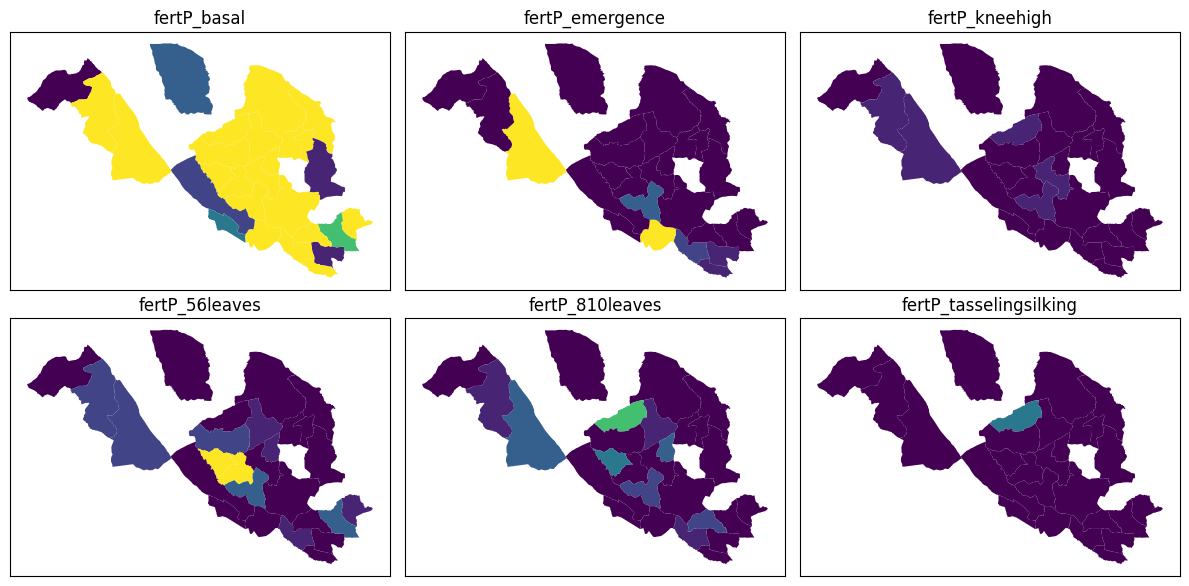

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for t, ax in zip(TIMINGS, axes): 
    points['value'] = data[f'fertP_{t}'] > 0
    admin['value'] = admin.ADM3_PCODE.map(points.groupby('ADM3_PCODE')['value'].sum().fillna(0))
    admin.plot('value', ax=ax, vmin=0, vmax=10, cmap='viridis')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'fertP_{t}')
plt.tight_layout()

In [16]:
# data[treatment_name] = data[treatment_name] > 0
T_series = data[treatment_name]
Y_series = data[outcome_name]

transformed_data = pd.DataFrame(index=data.index)
# Normalize features
numeric_features = list(data[features].select_dtypes(include='number').columns)
dummy_features = [
    'history_rootandtuber', 'history_nocrop', 'history_legume', 'history_oilseed',
    'history_maize', 'crop_maize', 'manure_any', 
    'variety_recycled', 'variety_hybrid', 'treat_previousadvice'
]
index_features = [
    'accessibility_rai', 'neighbor_previousadvice_avg', 'techaccess_index',
    'knowledge_index'
]
timing_features = [f'fertP_{t}' for t in TIMINGS[:]]

numeric_features = list((set(numeric_features) - set(dummy_features)) - set(timing_features))
# numeric_features = list(numeric_features - set(index_features))

transformed_data[numeric_features] = StandardScaler().fit_transform(
    data[numeric_features]
).astype(np.float32)
transformed_data[dummy_features] = data[dummy_features].astype(float)
transformed_data[timing_features] = data[timing_features]
# transformed_data[index_features] = data[index_features].astype(np.float32)

# Transform the outcome crop-wise
tmp_series = data.loc[data.crop_maize, 'outcome_prodkgha']
transformed_data['outcome_prodstd'] = (tmp_series - tmp_series.mean())/tmp_series.std()
tmp_series = data.loc[~data.crop_maize, 'outcome_prodkgha']
transformed_data['outcome_prodstd'] = transformed_data.outcome_prodstd.fillna(
    (tmp_series - tmp_series.mean())/tmp_series.std()
)
# Drop those rows with no production
transformed_data = transformed_data.loc[transformed_data.outcome_prodstd.notna()]
# Drop rows with values not within feasible range
NORMALIZED_LIM = 5
transformed_data = transformed_data.loc[
    (transformed_data < NORMALIZED_LIM).all(axis=1) & 
    (transformed_data > -NORMALIZED_LIM).all(axis=1)
]
# Redefine index of samples
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [17]:
# Spatially demean the outcome
spatial_transformer = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer.fit(transformed_data.outcome_prodstd)
transformed_data['outcome_prodstd'] = spatial_transformer.transform_demean()

In [18]:
# Add treatment and Keep only complete records
transformed_data[treatment_name] = data[treatment_name]
transformed_data = transformed_data.dropna()
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [20]:
transformed_data.describe().transpose().sort_index()

,count,mean,std,min,25%,50%,75%,max
accessibility_rai,713.0,0.008322,1.009883,-2.598903,-0.924301,0.945604,0.945604,0.945604
crop_maize,713.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
elevation_value,713.0,0.099970,0.978925,-2.343561,-0.630718,0.158610,0.750607,4.160505
fertN_56leaves,713.0,0.028212,1.004071,-0.921755,-0.921755,-0.173944,0.837193,2.509423
fertN_810leaves,713.0,0.048908,0.987668,-1.332594,-1.332594,0.158574,1.081536,1.676627
fertN_basal,713.0,-0.026897,0.960922,-2.192917,-0.609066,-0.253696,0.301569,4.388249
fertN_emergence,713.0,-0.092054,0.661020,-0.242606,-0.242606,-0.242606,-0.242606,4.846807
fertN_kneehigh,713.0,0.003090,1.006453,-0.356919,-0.356919,-0.356919,-0.356919,3.756810
fertN_tasselingsilking,713.0,-0.096192,0.579276,-0.191740,-0.191740,-0.191740,-0.191740,4.499659
fertN_total,713.0,0.573689,0.681949,-0.803606,0.073480,0.487010,0.957771,2.680342


# Effect of the fertilizer

## Generalized propensity score

In [21]:
x_names = timing_features
w_names = list(set(features) - set(x_names))

training_idxs, testing_idxs = train_test_split(index_zone_subset, random_state=RANDOM_SEED)
print(f"{len(training_idxs)} training samples")
print(f"{len(testing_idxs)} testing samples")
print(f'N features: {len(x_names)+len(w_names)}')

534 training samples
179 testing samples
N features: 45


In [22]:
# First we need a model for the treatment
X_train = transformed_data.loc[training_idxs, w_names + x_names]
t_train = transformed_data.loc[training_idxs, treatment_name]

optimizer_treatment = GPOptimizer(
    model=GradientBoostingRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=6),
        # max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        # min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        learning_rate=Real(name='learning_rate', low=1e-3, high=1), 
        n_estimators=1000, n_iter_no_change=20, max_features='sqrt',
        random_state=RANDOM_SEED
    )
)
model_treatment, cv_scores_treatment = optimizer_treatment.cv_optimize(
    X_train, t_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=50, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [23]:
model_treatment = model_treatment.fit(X_train, t_train)
test_score = r2_score(
    y_true=transformed_data.loc[testing_idxs, treatment_name],
    y_pred=model_treatment.predict(transformed_data.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_treatment):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(t_train, model_treatment.predict(X_train)):.3f}')

CV R2 mean: 0.812
Test R2: 0.831
Train R2: 0.988


In [24]:
pd.Series(
    model_treatment.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

fertN_total               0.217874
history_oilseed           0.156612
fertN_810leaves           0.121754
wthstage_rain30to50       0.071117
knowledge_index           0.063209
treat_previousadvice      0.048791
accessibility_rai         0.035532
lat                       0.027870
fertN_tasselingsilking    0.027137
soilfert_cec              0.025887
dtype: float64

<Axes: ylabel='Count'>

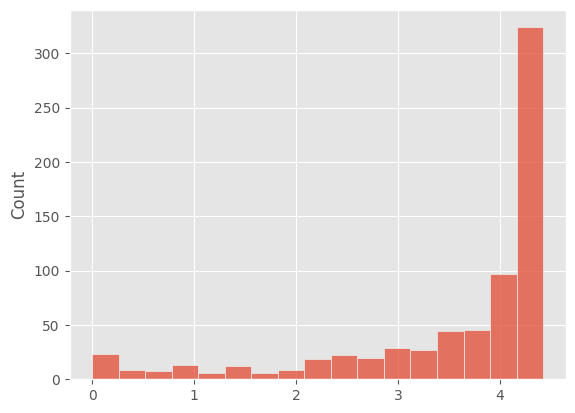

In [25]:
# Use Zhu et al. (2018) and Hirano and Gimbens (2004) approach to estimate PS for continuous treatments
from scipy import stats
T = transformed_data.loc[:, treatment_name].values
# Get the CV predictions to estimate the variance of residuals
T_pred = cross_val_predict(
    model_treatment, 
    X=transformed_data.loc[:, w_names + x_names],
    y=transformed_data.loc[:, treatment_name]
)
T_res = T - T_pred
res_var = np.var(T_res)

# Estimate the GPS
# gps = (1/(np.sqrt(2*np.pi*res_var)))*np.exp((-1/(2*res_var))*treatment_res**2)
gps_density = stats.norm.pdf(
    T, 
    loc=T_pred, 
    scale=res_var**.5 # Scale is sd in this function
)
plt.style.use('ggplot')
sns.histplot(gps_density)

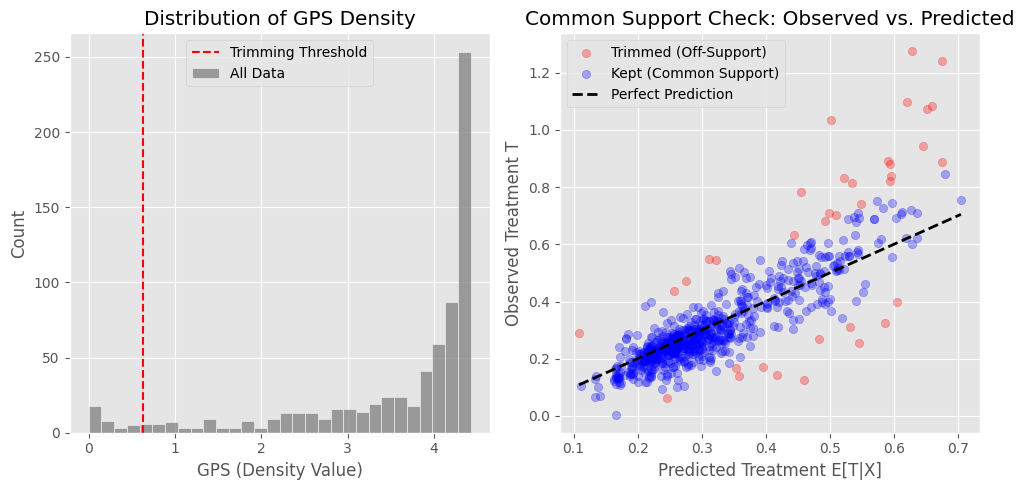

In [26]:
threshold = np.quantile(gps_density, 0.05)
mask_support = gps_density >= threshold
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax = axes[0]

sns.histplot(gps_density, bins=30, ax=axes[0], color='grey', label='All Data')
ax.axvline(threshold, color='red', linestyle='--', label='Trimming Threshold')
ax.set_title("Distribution of GPS Density")
ax.set_xlabel("GPS (Density Value)")
ax.legend()


ax = axes[1]
ax.scatter(T_pred[~mask_support], T[~mask_support], alpha=0.3, color='red', label='Trimmed (Off-Support)')
ax.scatter(T_pred[mask_support], T[mask_support], alpha=0.3, color='blue', label='Kept (Common Support)')
ax.plot([min(T_pred), max(T_pred)], [min(T_pred), max(T_pred)], 'k--', lw=2, label='Perfect Prediction')

ax.set_title("Common Support Check: Observed vs. Predicted")
ax.set_xlabel("Predicted Treatment E[T|X]")
ax.set_ylabel("Observed Treatment T")
ax.legend()

plt.tight_layout()
plt.show()

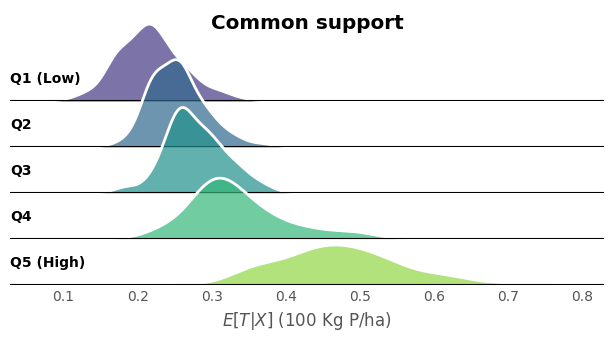

In [28]:
tmp_df = pd.DataFrame({'T_pred': T_pred[mask_support], 'Strata': pd.qcut(T[mask_support], 5, labels=False)})

g = sns.FacetGrid(tmp_df, row="Strata", hue="Strata", aspect=9, height=.75, palette="viridis")
g.map(sns.kdeplot, "T_pred", clip_on=False, fill=True, alpha=0.7, lw=0)
g.map(sns.kdeplot, "T_pred", clip_on=False, color="w", lw=2)

g.fig.subplots_adjust(hspace=-.5)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.axes.flat[0].set_title("Common support", fontweight='bold', y=.7) 
g.axes.flat[-1].set_xlabel(r'$E[T|X]$'+' (100 Kg P/ha)')

# Optional: Add text labels for each stratum
for ax, label in zip(g.axes.flat, ["Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"]):
    ax.text(0, 0.2, label, fontweight="bold", transform=ax.transAxes)
    ax.axhline(0, color='k', linestyle="-")
    ax.set_facecolor('none')
    ax.grid(None)
    ax.tick_params(length=0)

<Axes: ylabel='Density'>

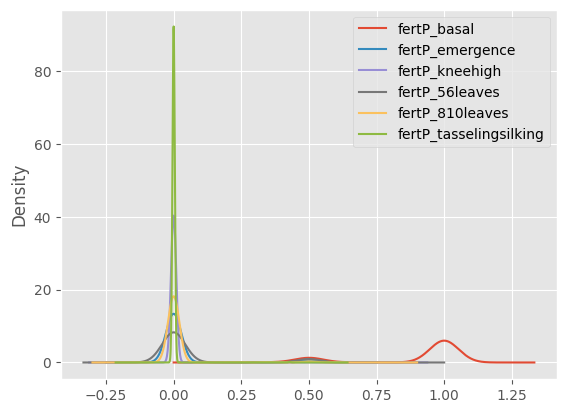

In [29]:
# Check the distribution of timing to select only those that have a good distribution
transformed_data.loc[:, timing_features].plot.kde()

In [30]:
# Trim extreme residuals
transformed_data_pstrimmed = transformed_data.copy()
transformed_data_pstrimmed = transformed_data_pstrimmed.loc[gps_density > threshold]

In [31]:
transformed_data_pstrimmed = transformed_data.copy()
index_zone_subset = transformed_data_pstrimmed.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data_pstrimmed.shape

(713, 47)

## Outcome model $q(X, W)$

In [37]:
y_train = transformed_data_pstrimmed.loc[training_idxs, outcome_name]

optimizer_q = GPOptimizer(
    model=RandomForestRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=10),
        max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        n_estimators=100, random_state=RANDOM_SEED
    )
)

# optimizer_q = GPOptimizer(
#     model=GradientBoostingRegressor,
#     model_kwargs=dict(
#         max_depth=Integer(name='max_depth', low=2, high=6),
#         # max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
#         # min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
#         learning_rate=Real(name='learning_rate', low=1e-3, high=1), 
#         n_estimators=1000, n_iter_no_change=20, max_features='sqrt',
#         random_state=RANDOM_SEED
#     )
# )
model_q, cv_scores_q = optimizer_q.cv_optimize(
    X_train, y_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=100, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [41]:
model_q = model_q.fit(X_train, y_train)
test_score = r2_score(
    y_true=transformed_data_pstrimmed.loc[testing_idxs, outcome_name],
    y_pred=model_q.predict(transformed_data_pstrimmed.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_q):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(y_train, model_q.predict(X_train)):.3f}')

CV R2 mean: -0.013
Test R2: 0.058
Train R2: 0.210


In [42]:
pd.Series(
    model_q.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

history_oilseed           0.201619
fertN_tasselingsilking    0.076457
wthstage_rain30to50       0.051332
fertP_810leaves           0.047771
soilfert_oc               0.043189
wthstage_rain10to30       0.042714
wthstage_rain20to40       0.041568
phenology_losstd          0.041009
knowledge_index           0.040837
fertN_emergence           0.033283
dtype: float64

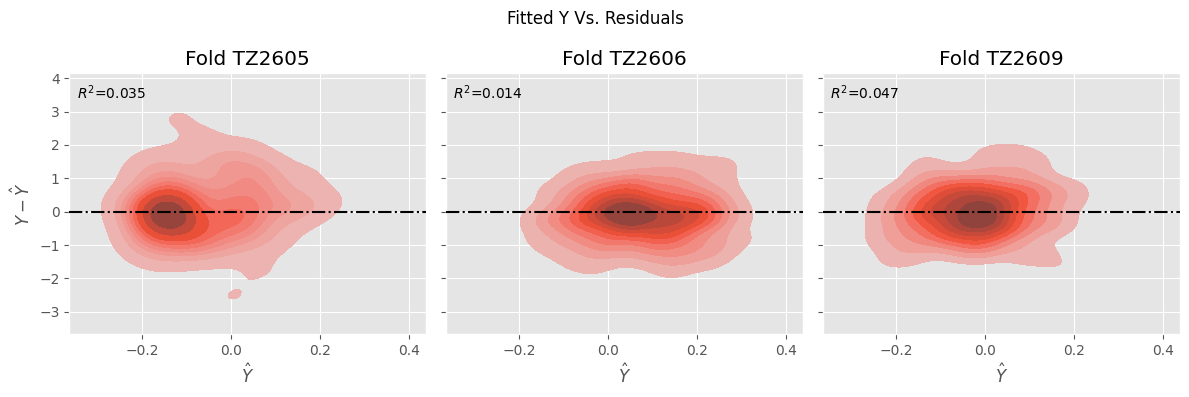

In [43]:
from sklearn.base import clone

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
axes = axes.flatten()
spatial_group = 'ADM2_PCODE'
groups = points[spatial_group].unique()

for n, gr in enumerate(groups):
    ax = axes[n]
    tmp_model = clone(model_q)
    tmp_idx = points.index[points[spatial_group] != gr]
    tmp_X = transformed_data_pstrimmed.loc[tmp_idx, w_names + x_names]
    tmp_y = transformed_data_pstrimmed.loc[tmp_idx, outcome_name]

    tmp_model = tmp_model.fit(tmp_X, tmp_y)

    tmp_idx = points.index[points[spatial_group] == gr]
    tmp_X = transformed_data_pstrimmed.loc[tmp_idx, w_names + x_names]
    tmp_y = transformed_data_pstrimmed.loc[tmp_idx, outcome_name]
    y_pred = tmp_model.predict(tmp_X)

    sns.kdeplot(
        x=y_pred, 
        y= tmp_y - y_pred,
        ax=ax,
        zorder=2, fill=True
    )
    
    ax.set_title(f'Fold {gr}')
    ax.axhline(0, color='k', zorder=3, linestyle='-.')
    ax.set_xlabel(r"$\hat{Y}$")
    ax.set_ylabel(r"$Y - \hat{Y}$")
    ax.text(
        0.02, 0.90, r'$R^2$='+f'{r2_score(tmp_y, y_pred):.3f}',
        transform=ax.transAxes
    )
fig.suptitle('Fitted Y Vs. Residuals')
plt.tight_layout()

## DML 

In [44]:
from econml.dml import LinearDML, SparseLinearDML, CausalForestDML
from econml.inference import BootstrapInference
N_BOOTSTRAP = 100
bootstrap = BootstrapInference(N_BOOTSTRAP, bootstrap_type='percentile')

### Homogeneous effect

In [45]:
W = transformed_data_pstrimmed.loc[:,features]
Y = transformed_data_pstrimmed.loc[:, outcome_name].to_numpy()
T = transformed_data_pstrimmed.loc[:, treatment_name].to_numpy()

lineardml_hom_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED
)
lineardml_hom_estimate = lineardml_hom_estimate.fit(
    Y=Y, T=T, W=W,
    inference=bootstrap, cache_values=True
)

In [46]:
lineardml_hom_estimate.ate_inference()

### Heterogeneous effect

In [47]:
W = transformed_data_pstrimmed.loc[:, list(set(features) - set(x_names))].to_numpy()
X = transformed_data_pstrimmed.loc[:, x_names].to_numpy()
Y = transformed_data_pstrimmed.loc[:, outcome_name].to_numpy()
T = transformed_data_pstrimmed.loc[:, treatment_name].to_numpy()

cf_estimator = CausalForestDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5, 
    random_state=RANDOM_SEED,
    fit_intercept=True,
    # Trees hyperparameters 
    criterion='het',
    # min_balancedness_tol=0.45
)
cf_estimator = cf_estimator.fit(
    Y=Y, T=T, X=X, W=W, 
    inference=bootstrap, cache_values=True
)
cf_estimator.score_

In [48]:
cf_estimator.ate_inference(X)

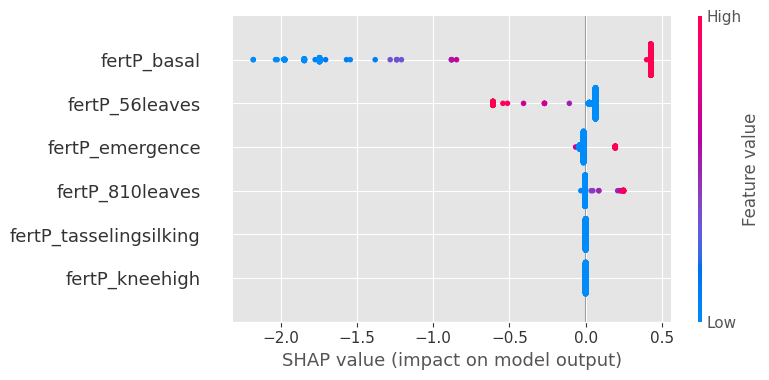

In [49]:
import shap

shap_values = cf_estimator.shap_values(X)
shap.summary_plot(shap_values['Y0']['T0'], feature_names=x_names)

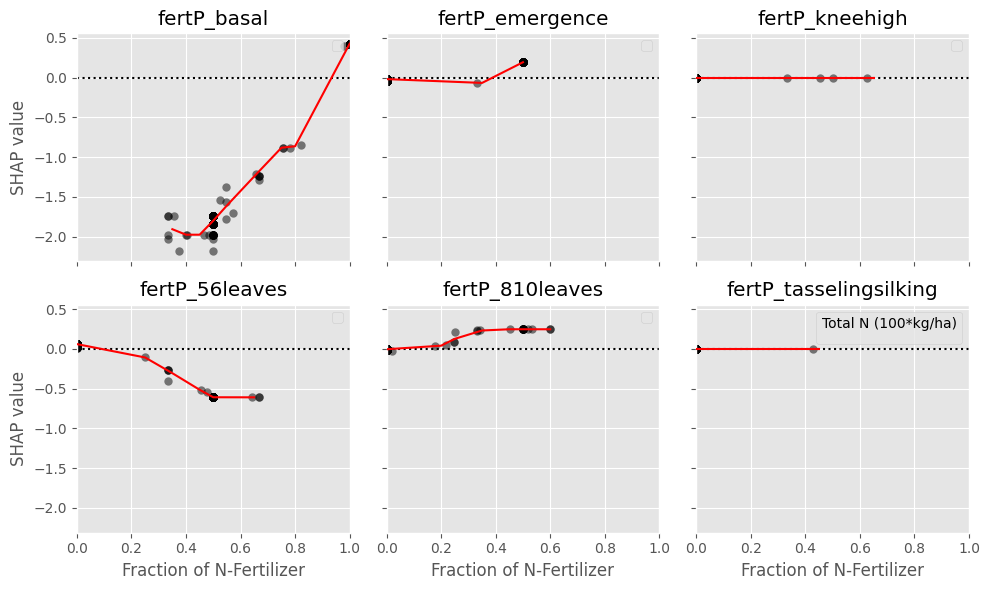

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()
for n, x_n in enumerate(x_names):
    ax = axes[n]
    sns.scatterplot(
        x=shap_values['Y0']['T0'].data[:, n],
        y=shap_values['Y0']['T0'].values[:, n],
        # hue=T, palette='inferno', 
        color='k', alpha=.5,
        ax=ax, linewidth=0, zorder=2,
    )
    x = np.round(shap_values['Y0']['T0'].data[:, n]*20)/20
    # sns.regplot(
    #     x=shap_values['Y0']['T0'].data[:, n],
    #     y=shap_values['Y0']['T0'].values[:, n],
    #     ax=ax, lowess=True, marker='.',
    #     line_kws=dict(color='k'),
    #     scatter_kws=dict(linewidths=0)
    # )
    sns.lineplot(
        x=np.round(shap_values['Y0']['T0'].data[:, n]*20)/20,
        y=shap_values['Y0']['T0'].values[:, n], zorder=3,
        ax=ax, color='r', errorbar=None
    )

    ax.set_title(x_n)
    ax.set_xlabel('Fraction of N-Fertilizer')
    ax.set_ylabel('SHAP value')
    ax.set_xlim(0, 1)
    ax.axhline(0, linestyle=':', color="k", zorder=1)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend('')
ax.legend(handles, labels, ncols=2, title='Total N (100*kg/ha)')

plt.tight_layout()


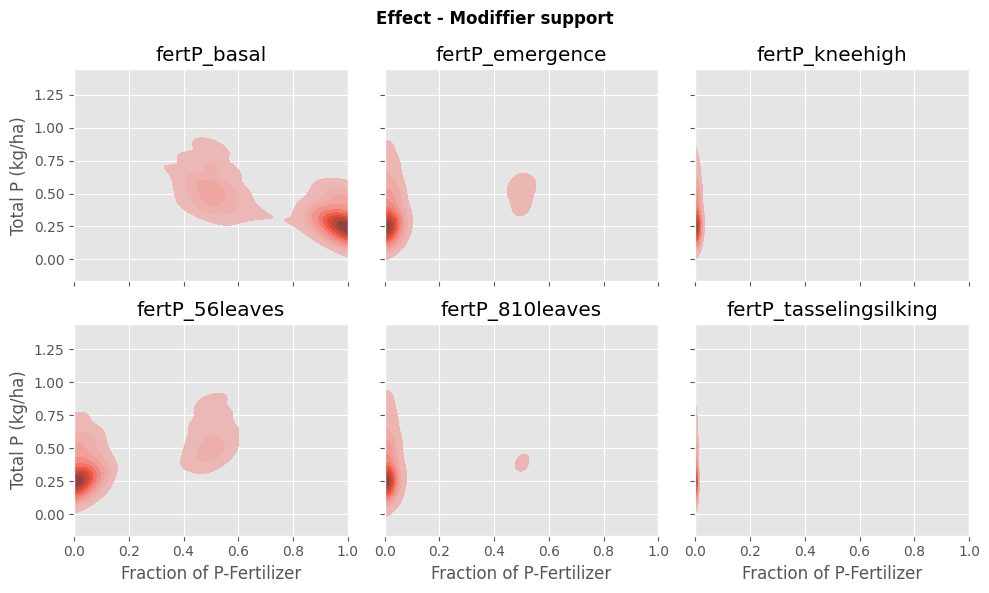

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()
for n, x_n in enumerate(x_names):
    ax = axes[n]
    sns.kdeplot(
        transformed_data_pstrimmed,
        x=x_n,
        y=treatment_name, 
        fill=True, ax=ax
    )
    ax.set_title(x_n)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Fraction of P-Fertilizer')
    ax.set_ylabel('Total P (kg/ha)')
plt.suptitle('Effect - Modiffier support', fontweight='bold')
plt.tight_layout()

In [54]:
# Shap values of individual estimators
from tqdm import tqdm

shap_values_instances = []
for est_instance in tqdm(cf_estimator._inference._est._instances):
    shap_values_instances.append(est_instance.shap_values(X))

100%|██████████| 100/100 [00:17<00:00,  5.79it/s]


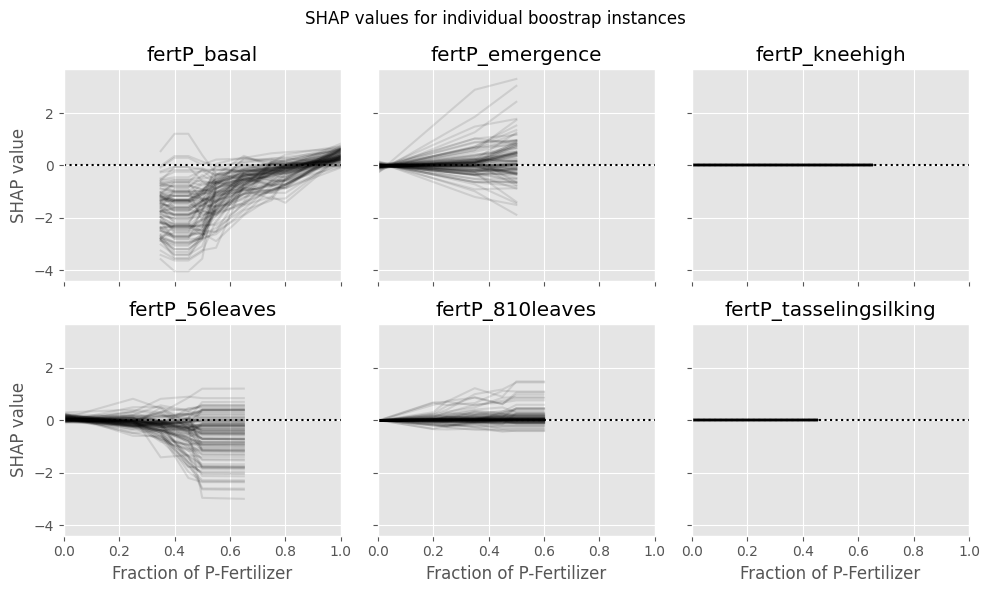

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()
for n, x in enumerate(x_names):
    ax = axes[n]
    for shap_vals in shap_values_instances:
        sns.lineplot(
            x=np.round(shap_vals['Y0']['T0'].data[:, n]*20)/20,
            y=shap_vals['Y0']['T0'].values[:, n],
            ax=ax, color='k', errorbar=None, alpha=.1
        )
    ax.set_title(x)
    ax.set_xlabel('Fraction of P-Fertilizer')
    ax.set_ylabel('SHAP value')
    ax.set_xlim(0, 1)
    ax.axhline(0, linestyle=':', color="k", zorder=1)
fig.suptitle('SHAP values for individual boostrap instances')
plt.tight_layout()


Text(50.722222222222214, 0.5, '810Leaves application as % of total')

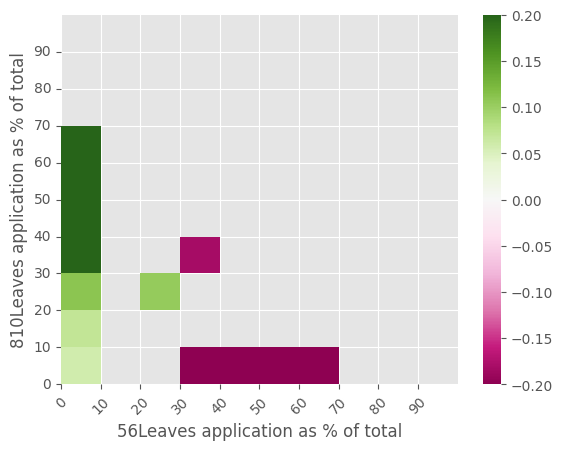

In [56]:
shap_cmap = mpl.colors.LinearSegmentedColormap.from_list("", ['#f4006e','#008bfb'])

def shap_interaction_array(x0, x1, bins=np.linspace(0.025, .975, 20)):
    res = bins[1:] - bins[:-1]
    res = res.mean()/2

    x=shap_values['Y0']['T0'].data[:, x0]
    y=shap_values['Y0']['T0'].data[:, x1]
    z=shap_values['Y0']['T0'].values[:, [x0, x1]].sum(axis=1)
    zz = np.ones(shape=(len(bins), len(bins)))

    for i, y_i in enumerate(bins):
        y_mask = (y >= y_i-res) & (y <= y_i +res)
        for j, x_j in enumerate(bins):
            x_mask = (x >= x_j-res) & (x <= x_j +res)
            zz[i][j] = z[y_mask & x_mask].mean()
    return zz[::-1]

fig, ax = plt.subplots()   
bins = np.linspace(0.05, .95, 10)
x0 = 3; x1 = 4
zz = shap_interaction_array(x0, x1, bins)
sns.heatmap(
    zz, cmap='PiYG', ax=ax, vmin=-0.2, vmax=0.2
)
ax.set_xticks(ax.get_xticks()-.5); ax.set_yticks(ax.get_yticks()+.5)
ax.set_xticklabels([f'{b*100:.0f}' for b in bins-.05], rotation=45)
ax.set_yticklabels([f'{b*100:.0f}' for b in bins-.05][::-1], rotation=0)
ax.set_xlabel(f'{TIMINGS[x0].title()} application as % of total')
ax.set_ylabel(f'{TIMINGS[x1].title()} application as % of total')

In [60]:
maize_std = clean_data.loc[index_zone_subset].maizeprodkg_ha.std()
soya_std = clean_data.loc[index_zone_subset].soyaprodkg_ha.std()
maize_std * np.array([cf_estimator.ate(X), lineardml_hom_estimate.ate()])/100

array([57.30682437, 40.50472799])

In [61]:
np.array(cf_estimator.nuisance_scores_).mean(axis=2), np.array(cf_estimator.nuisance_scores_).std(axis=2)

(array([[0.02819941],
        [0.82083684]]),
 array([[0.0329495 ],
        [0.03751122]]))

## Sensitivity analysis

In [62]:
cf_estimator.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
===============================================
CI Lower Theta Lower Theta Theta Upper CI Upper
-----------------------------------------------
   1.097       1.946 2.478        3.01    3.846
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.212                 0.142
----------------------------------------------
"""

## Placebo test

In [63]:
placebo_estimates = []
placebo_shaps = []

for _ in tqdm(range(N_BOOTSTRAP)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)

    cf_placebo_estimator = CausalForestDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5, 
        random_state=RANDOM_SEED,
        fit_intercept=True,
        # Trees hyperparameters 
        criterion='het',
        # min_balancedness_tol=0.45
    )
    cf_placebo_estimator = cf_placebo_estimator.fit(
        Y=Y, T=T_placebo, X=X, W=W, 
        inference=None, cache_values=True
    )
    placebo_estimates.append((
        cf_placebo_estimator.ate(X),
    ))
    placebo_shaps.append(cf_placebo_estimator.shap_values(X))

100%|██████████| 100/100 [01:54<00:00,  1.14s/it]


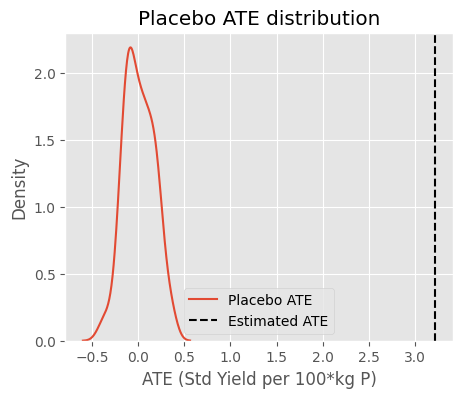

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.kdeplot(np.array(placebo_estimates).flatten(), label='Placebo ATE')
ax.set_xlabel('ATE (Std Yield per 100*kg P)')
ax.set_title('Placebo ATE distribution')
ax.axvline(cf_estimator.ate(X), label='Estimated ATE', color='k', linestyle='--')
ax.legend()

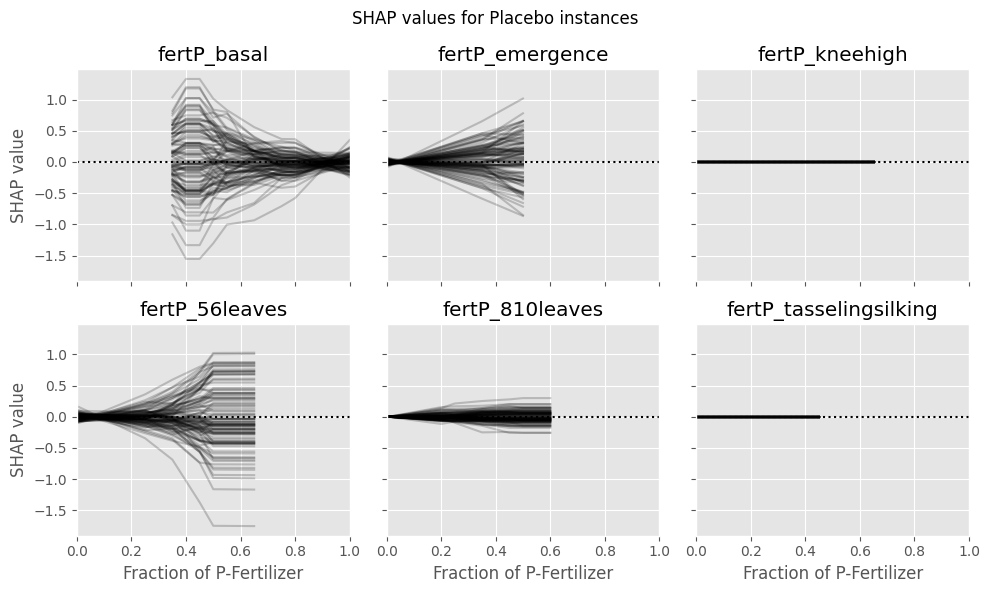

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()
for n, x in enumerate(x_names):
    ax = axes[n]
    for shap_vals in placebo_shaps:
        sns.lineplot(
            x=np.round(shap_vals['Y0']['T0'].data[:, n]*20)/20,
            y=shap_vals['Y0']['T0'].values[:, n],
            ax=ax, color='k', errorbar=None, alpha=.2
        )
    ax.set_title(x)
    ax.set_xlabel('Fraction of P-Fertilizer')
    ax.set_ylabel('SHAP value')
    ax.set_xlim(0, 1)
    ax.axhline(0, linestyle=':', color="k", zorder=1)
fig.suptitle('SHAP values for Placebo instances')
plt.tight_layout()


In [77]:
from statsmodels.formula.api import ols
ols_model = ols(
    data=transformed_data_pstrimmed,
    formula=f'{outcome_name} ~ {treatment_name} + ' + '+'.join(w_names)
).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        outcome_prodstd   R-squared:                       0.177
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     3.722
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           1.67e-12
Time:                        17:15:22   Log-Likelihood:                -744.23
No. Observations:                 713   AIC:                             1568.
Df Residuals:                     673   BIC:                             1751.
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.2368      0.093     -2.536      0.011      -0.420      -0.053
fertP_total                     0.5112      0.218      2.344      0.019       0.083       0.939
wthseason_rain                  0.0432      0.314      0.138      0.891      -0.573       0.659
fertN_kneehigh               9.085e+05   7.37e+05      1.232      0.218   -5.39e+05    2.36e+06
variety_hybrid                 -0.3183      0.187     -1.700      0.090      -0.686       0.049
soilpp_clay                    -0.1622      0.087     -1.858      0.064      -0.334       0.009
soilfert_cec                   -0.0153      0.047     -0.327      0.744      -0.107       0.077
fertN_emergence              4.732e+05   3.84e+05      1.232      0.218   -2.81e+05    1.23e+06
neighbor_previousadvice_avg    -0.0721      0.045     -1.587      0.113      -0.161       0.017
soilpp_sand                     0.0137      0.085      0.162      0.871      -0.152       0.180
fertN_tasselingsilking       4.122e+05   3.34e+05      1.232      0.218   -2.45e+05    1.07e+06
fieldsize_value                -0.0378      0.046     -0.818      0.414      -0.128       0.053
history_oilseed                -0.4668      0.741     -0.630      0.529      -1.922       0.988
wthstage_rain20to40            -0.0242      0.070     -0.348      0.728      -0.161       0.113
fertN_total                     0.3907      0.054      7.182      0.000       0.284       0.498
wthstage_rainp40to100           0.0245      0.237      0.103      0.918      -0.440       0.489
soilpp_density                 -0.0552      0.065     -0.848      0.397      -0.183       0.073
lat                             0.0359      0.059      0.614      0.540      -0.079       0.151
knowledge_index                -0.0542      0.035     -1.543      0.123      -0.123       0.015
wthseason_tmean                 0.0168      0.083      0.203      0.839      -0.146       0.179
history_rootandtuber           -0.0380      0.294     -0.129      0.897      -0.615       0.539
wthstage_rain30to50            -0.0100      0.042     -0.237      0.813      -0.093       0.073
fertN_basal                  4.773e+05   3.87e+05      1.232      0.218   -2.83e+05    1.24e+06
crop_maize                     -0.2386      0.094     -2.552      0.011      -0.422      -0.055
history_maize                   0.0260      0.171      0.152      0.880      -0.311       0.363
elevation_value                 0.0341      0.075      0.453      0.651      -0.114       0.182
soilfert_oc                     0.0291      0.080      0.363      0.717      -0.129       0.187
phenology_losstd               -0.0150      0.047     -0.323      0.747      -0.107       0.076
wthstage_rain10to30            -0.0150      0.072     -0.209      0.834      -0.156       0.126
wthstage_ra

In [78]:
0.5112/100 * maize_std

In [68]:
timing_options = []

perc = np.arange(0, 30, 10)/100
for v56 in perc:
    for v810 in perc:
        if v56 + v810 > 1:
            continue
        timing_options.append((v56, v810))

def get_best_splitting(est):
    best = None
    ci_low = -99
    for op in timing_options:
        op = np.array(op)
        op = (1-sum(op), 0, 0, op[0], op[1], 0)
        ci = est.ate_interval([op])
        if ci[0] > ci_low:
            ci_best = ci
            ci_low = ci[0]
            best = op
    return (*best, *ci_best)

len(timing_options)

In [69]:
def to_pct_10(X):
    res = (X * 10).astype(int)
    k = 10 - res.sum()
    res[np.argsort(X * 10 - res)[res.size - k:]] += 1
    return res * 10

In [70]:
pd.Series([tuple(to_pct_10(i)) for i in X]).value_counts().head()

(100, 0, 0, 0, 0, 0)    572
(50, 0, 0, 50, 0, 0)     74
(50, 50, 0, 0, 0, 0)     33
(50, 0, 0, 0, 50, 0)     13
(80, 0, 0, 0, 20, 0)      4
Name: count, dtype: int64

In [71]:
# get_best_splitting(cf_estimator)  

In [73]:
# Optimal is estimated as the rounded average of the top 5 applications with
# the higher low confidence intervals
optimal_application = (0.8, 0, 0, .2, .0, 0)
applications_to_compare = [
    (1, 0, 0, 0, 0, 0), # All basal (most common)
    (0.5, 0, 0., 0.5, 0, 0), # Second most common
    optimal_application, # Optimal
]
inferences_dict = {}
for ap in applications_to_compare:
    print(ap)
    inferences_dict[ap] = cf_estimator.ate_inference([ap])

(1, 0, 0, 0, 0, 0)
(0.5, 0, 0.0, 0.5, 0, 0)
(0.8, 0, 0, 0.2, 0.0, 0)


,value,ci_low,ci_high
100% Basal,3.719911,2.090981,5.348841
"50% Basal, 50% V5-6",1.030691,-0.416131,2.477513
"80% Basal, 20% V5-6",1.382262,0.007917,2.756608


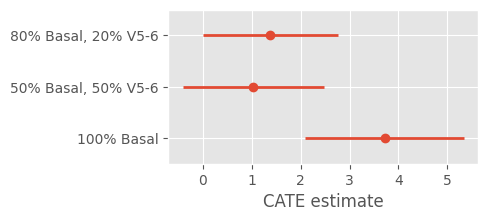

In [74]:
tmp_df = pd.DataFrame(columns=['value', 'ci_low', 'ci_high'], index=applications_to_compare)
for ap, infer in inferences_dict.items():
    tmp_df.loc[[ap]] = infer.mean_point, *infer.conf_int_mean()

timing_names = [
    'Basal', 'Emergence', 'Knee-high', 'V5-6',
    'V8-10', 'Tasseling-Silking' 
]
def format_application(app_tuple):
    items = [f"{val:.0%} {name}" for val, name in zip(app_tuple, timing_names) if val > 0]
    return ",\n".join([", ".join(items[i:i+2]) for i in range(0, len(items), 2)])

tmp_df.index = [format_application(i) for i in applications_to_compare]

fig, ax = plt.subplots(1, 1, figsize=(4, 2))
ax.errorbar(
    y=tmp_df.index,
    x=tmp_df['value'],
    xerr=np.abs(tmp_df[['ci_low', 'ci_high']].values.T - tmp_df['value'].values),
    fmt='o', linewidth=2
)
ax.set_xlabel('CATE estimate')
ax.set_ylim(-0.5, 2.5)
# plt.tight_layout()
tmp_df

In [75]:
exp_df = transformed_data_pstrimmed.knowledge_index.to_frame()
exp_df['n_applications'] = (transformed_data_pstrimmed[x_names] > 0).sum(axis=1)
exp_df['distance'] = np.sqrt(np.sum((transformed_data_pstrimmed[x_names].values - np.array([optimal_application]))**2, axis=1))
exp_df[TIMINGS] = np.abs(transformed_data_pstrimmed[x_names].values - np.array([optimal_application]))

exp_df['amount'] = transformed_data_pstrimmed[treatment_name]
exp_df['N amount tercile'] = pd.qcut(exp_df['amount'], q=3, labels=['Low', 'Med', 'High'])
exp_df[outcome_name] = transformed_data_pstrimmed[outcome_name]
exp_df['treat_previousadvice'] = transformed_data_pstrimmed.treat_previousadvice

exp_df.groupby('N amount tercile').amount.describe()

,count,mean,std,min,25%,50%,75%,max
N amount tercile,,,,,,,,
Low,238.0,0.186343,0.040344,0.004567,0.160467,0.196015,0.220565,0.235303
Med,237.0,0.271919,0.022983,0.235359,0.251991,0.270378,0.288542,0.321754
High,238.0,0.500543,0.169058,0.322995,0.381432,0.458599,0.560475,1.274569


In [ ]:
# effects_df.to_pickle(f'../data/effects-{timing}-west.pkl')
# transformed_data_pstrimmed.to_pickle(f'../data/transformed-subset-pstrimmed-{timing}-west.pkl')
# coefs_instances.to_pickle(f'../data/coefs-dmllinear-instances-{timing}-west.pkl')
# coefs_instances_placebo.to_pickle(f'../data/coefs-dmllinear-instances-placebo-{timing}-west.pkl')